In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kruskal, mannwhitneyu

[Swap(5), Swap(4), Swap(3), Swap(2), Swap(1)]

[Swap(1), Swap(2), Swap(3), Swap(4), Swap(5)]

In [2]:
def plot_boxplots(filename, title):
    data = np.load(filename)
    outer_array = data[data.files[0]] 

    plt.figure()
    plt.title(f"{title}")
    plt.boxplot(outer_array.T, notch=True)
    plt.xlabel("Array Index")
    plt.ylabel("Values")
    plt.show()

In [3]:
# Deterministic
filename = 'FX_values_3_0.npz'
data = np.load(filename)
data = data["FX_values_"]
a0 = data[0, :]
b0 = data[1, :]

# Stochastic
filename = 'FX_values_3_1.npz'
data = np.load(filename)
data = data["FX_values_"]
a1 = data[0, :]
b1 = data[1, :]

## Deterministic

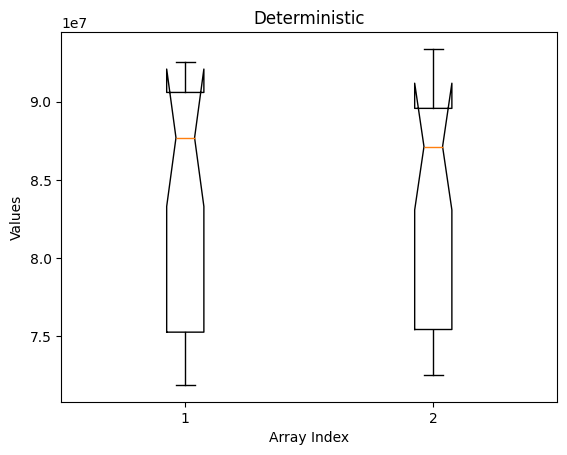

In [4]:
filename = 'FX_values_3_0.npz'
plot_boxplots(filename, "Deterministic")

In [5]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a0))
print(shapiro(b0))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.7922827401672332, pvalue=4.757646857372582e-05)
ShapiroResult(statistic=0.85599548498581, pvalue=0.0008299851415928851)


In [6]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a0, b0, alternative='two-sided')}")

a vs b: MannwhitneyuResult(statistic=451.0, pvalue=0.9941019213254952)


There's no significant difference between a and b.

## Stochastic

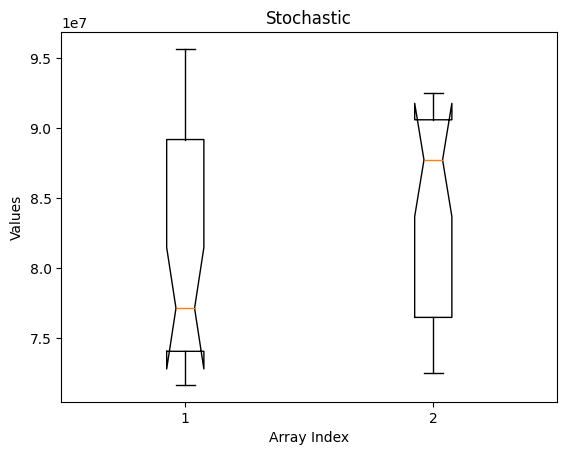

In [7]:
filename = 'FX_values_3_1.npz'
plot_boxplots(filename, "Stochastic")

In [8]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a1))
print(shapiro(b1))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.8372572845460683, pvalue=0.00033928659432703193)
ShapiroResult(statistic=0.8248251499721089, pvalue=0.00019239180007450834)


In [9]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a1, b1, alternative='two-sided')}")

a vs b: MannwhitneyuResult(statistic=322.0, pvalue=0.0594279151689524)


There's no significant difference between a and b. But the p-value is very close to be less than 0.05

# Deterministic x Stochastic

In [10]:
print(f"a0 vs a1: {mannwhitneyu(a0, a1, alternative='two-sided')}")
print(f"b0 vs b1: {mannwhitneyu(b0, b1, alternative='two-sided')}")

a0 vs a1: MannwhitneyuResult(statistic=542.0, pvalue=0.1761275454839878)
b0 vs b1: MannwhitneyuResult(statistic=411.0, pvalue=0.5692201637415295)


For a0 vs a1 and b0 vs b1, the high p-values indicate no significant difference between the groups.